# RFM and RG-VFM on the 2D checkerboard

This notebook evaluates an RFM model by default on the periodic 2D checkerboard in $T^2=[0,1)^2$. It can run the same evaluation for RG-VFM, loads a compatible checkpoint automatically, generates samples from the uniform torus prior, visualizes the learned flow, and reports both training-objective and distribution-level metrics.

## 1. Setup

Set `FLAT_TORUS_METHOD=rfm` (default) or `FLAT_TORUS_METHOD=rgvfm`. The sample count, ODE steps, and checkpoint can be overridden with `FLAT_TORUS_N_SAMPLES`, `FLAT_TORUS_N_STEPS`, and `FLAT_TORUS_CHECKPOINT`.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.patches import Rectangle
from torch.utils.data import DataLoader

# Make imports work whether Jupyter starts in the repository root or nearby.
PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'src').is_dir() and (path / 'checkpoints').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataLib.synthetic import Checkerboard_Dataset
from src.device import get_default_device
from src.flow_matching import RFM, RGVFM
from src.litTrain.evalFlatTorus2D import build_model_from_checkpoint, find_checkpoint
from src.manifolds import FlatTorus01

SEED = 2026
N_ROWS = 4
METHOD = os.getenv('FLAT_TORUS_METHOD', 'rgvfm').lower()
if METHOD not in {'rfm', 'rgvfm'}:
    raise ValueError('FLAT_TORUS_METHOD must be rfm or rgvfm')
MODEL_LABEL = 'RFM' if METHOD == 'rfm' else 'RG-VFM'
N_SAMPLES = int(os.getenv('FLAT_TORUS_N_SAMPLES', '4096'))
N_STEPS = int(os.getenv('FLAT_TORUS_N_STEPS', '100'))
TEST_BATCH_SIZE = 512
DEVICE = get_default_device()

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'project={PROJECT_ROOT}')
print(f'method={MODEL_LABEL}, device={DEVICE}, samples={N_SAMPLES}, ODE steps={N_STEPS}')

project=/Users/jizho/project_codes/diffusion-playground
method=RG-VFM, device=mps, samples=4096, ODE steps=100


## 2. Restore the trained model

The best distribution-selected checkpoint for the requested method is preferred. The model architecture and periodic input encoding are inferred from its weights, so both new RFM and legacy RG-VFM checkpoints can be evaluated safely.

In [2]:
checkpoint_override = os.getenv('FLAT_TORUS_CHECKPOINT')
if checkpoint_override:
    CHECKPOINT_PATH = Path(checkpoint_override).expanduser()
    if not CHECKPOINT_PATH.is_absolute():
        CHECKPOINT_PATH = PROJECT_ROOT / CHECKPOINT_PATH
else:
    CHECKPOINT_PATH = find_checkpoint(PROJECT_ROOT, METHOD)

manifold = FlatTorus01(dim=2)
CHECKPOINT_PATH = (PROJECT_ROOT / 'checkpoints/20260827_133135/RGVFMMLP_checkerboard_fractional/rgvfm_mlp_0178-0.054184.ckpt')
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=True)
model = build_model_from_checkpoint(
    checkpoint, method=METHOD, manifold=manifold
).to(DEVICE)
model.eval()

if METHOD == 'rfm':
    flow = RFM(manifold, normalize_loss=False, integrator='euler')
else:
    flow = RGVFM(
        manifold, noise_scale=0.001, max_velocity_scale=20.0,
        normalize_loss=False, support='intrinsic', integrator='euler',
    )

print(f'checkpoint: {CHECKPOINT_PATH.relative_to(PROJECT_ROOT)}')
print(f'method: {MODEL_LABEL}')
print(f'epoch: {checkpoint.get("epoch", "unknown")}')

checkpoint: checkpoints/20260827_133135/RGVFMMLP_checkerboard_fractional/rgvfm_mlp_0178-0.054184.ckpt
method: RG-VFM
epoch: 178


## 3. Held-out training-objective loss

This repeats the selected method's training objective on deterministic, unseen checkerboard points. RFM reports tangent-velocity MSE; RG-VFM reports terminal-point geodesic loss. This value should be interpreted together with the generated-distribution metrics below.

In [3]:
test_dataset = Checkerboard_Dataset(
    num_rows=N_ROWS, dataset_size=4096, seed=50_000, dim=2
)
test_loader = DataLoader(
    test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False
)

test_losses = []
with torch.inference_mode():
    for x_data in test_loader:
        x_data = x_data.to(DEVICE)
        t, x_t, target = flow.sample_training_pair(x_data)
        prediction = model(t, x_t)
        test_losses.append(
            flow.loss(prediction, target, x_t=x_t, t=t).cpu()
        )

heldout_loss = torch.stack(test_losses).mean().item()
objective_name = 'velocity MSE' if METHOD == 'rfm' else 'geodesic endpoint loss'
print(f'held-out {objective_name}: {heldout_loss:.6f}')

held-out geodesic endpoint loss: 1.895417


## 4. Generate checkerboard samples

The learned ODE transports a uniform prior on $T^2$ from $t=0$ to $t=1$. The full trajectory is retained for snapshot plots.

In [4]:
with torch.inference_mode():
    x_0 = flow.sample_prior(
        (N_SAMPLES, 2), device=DEVICE, dtype=next(model.parameters()).dtype
    )
    time_grid, trajectory = flow.sample(
        model, x_0, n_steps=N_STEPS, return_trajectory=True
    )

generated = manifold.wrap(trajectory[-1]).cpu()
prior = x_0.cpu()
reference = torch.stack(
    [Checkerboard_Dataset(N_ROWS, seed=80_000, dim=2)[i] for i in range(N_SAMPLES)]
)
trajectory_cpu = trajectory.cpu()
time_grid_cpu = time_grid.cpu()

assert generated.shape == (N_SAMPLES, 2)
assert torch.all((generated >= 0) & (generated < 1))
print(f'generated {len(generated)} valid torus samples')

generated 4096 valid torus samples


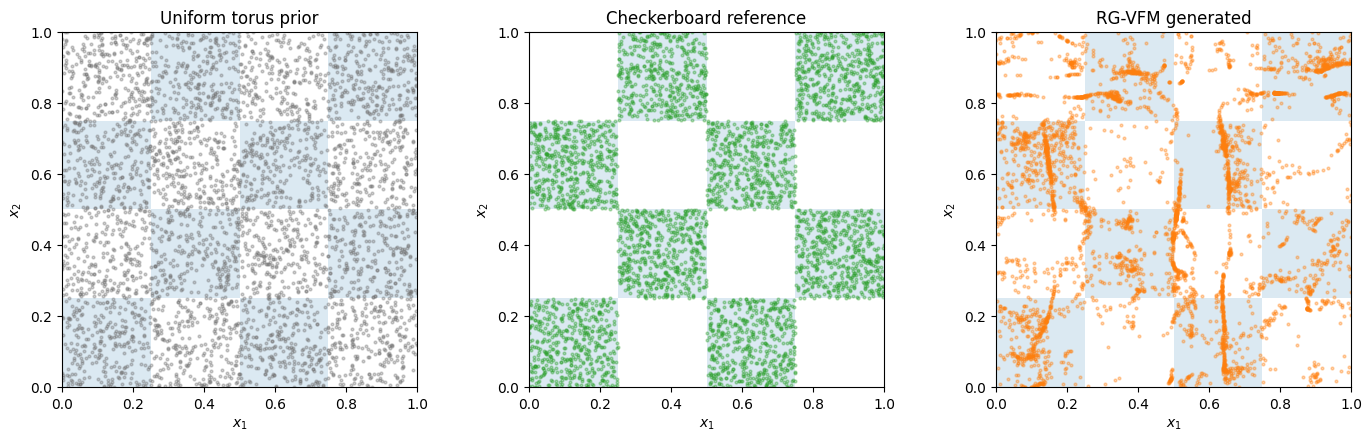

In [5]:
def draw_unit_checkerboard(ax, n_rows=N_ROWS, color='tab:blue', alpha=0.16):
    tile_size = 1.0 / n_rows
    for i in range(n_rows):
        for j in range(n_rows):
            if (i + j) % 2 == 0:
                ax.add_patch(Rectangle(
                    (i * tile_size, j * tile_size),
                    tile_size, tile_size, facecolor=color, edgecolor='none', alpha=alpha
                ))
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='$x_1$', ylabel='$x_2$')
    ax.set_aspect('equal')


fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)
for ax, points, title, color in zip(
    axes,
    [prior, reference, generated],
    ['Uniform torus prior', 'Checkerboard reference', f'{MODEL_LABEL} generated'],
    ['0.45', 'tab:green', 'tab:orange'],
):
    draw_unit_checkerboard(ax)
    ax.scatter(points[:, 0], points[:, 1], s=4, alpha=0.35, c=color, rasterized=True)
    ax.set_title(title)
plt.show()

## 5. Learned transport trajectory

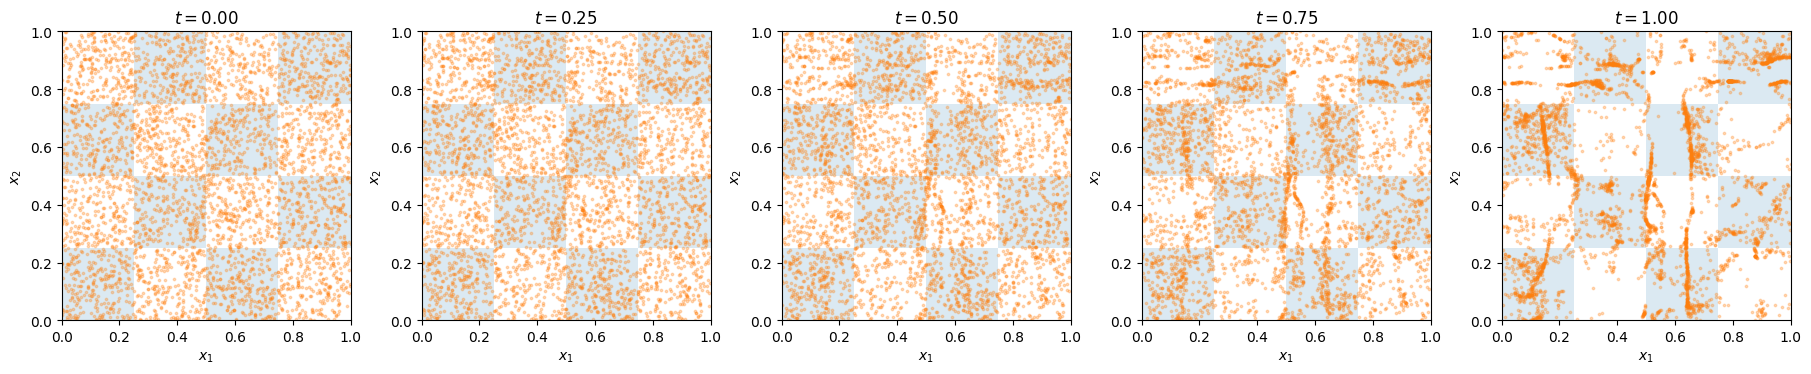

In [6]:
snapshot_fractions = [0.0, 0.25, 0.5, 0.75, 1.0]
snapshot_indices = [round(fraction * N_STEPS) for fraction in snapshot_fractions]
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), constrained_layout=True)
for ax, index in zip(axes, snapshot_indices):
    points = manifold.wrap(trajectory_cpu[index])
    draw_unit_checkerboard(ax)
    ax.scatter(points[:, 0], points[:, 1], s=3, alpha=0.28, c='tab:orange', rasterized=True)
    ax.set_title(f'$t={time_grid_cpu[index].item():.2f}$')
plt.show()

## 6. Distribution-level metrics

`valid_tile_rate` is the fraction of points in the eight occupied checkerboard tiles (ideal: 1; uniform prior: about 0.5). `histogram_TV_to_target` is the total-variation distance from the analytical checkerboard histogram (lower is better). The independent reference row gives the finite-sample noise floor for the chosen sample count.

In [7]:
def valid_tile_rate(points: torch.Tensor, n_rows=N_ROWS) -> float:
    tile = torch.floor(points * n_rows).long().clamp(0, n_rows - 1)
    return ((tile[:, 0] + tile[:, 1]) % 2 == 0).float().mean().item()


def histogram_tv_to_target(points: torch.Tensor, bins=16, n_rows=N_ROWS) -> float:
    if bins % n_rows != 0:
        raise ValueError('bins must be divisible by n_rows')
    observed = np.histogram2d(
        points[:, 0].numpy(), points[:, 1].numpy(),
        bins=bins, range=[[0, 1], [0, 1]],
    )[0]
    observed = observed / observed.sum()

    bin_index = np.arange(bins)
    tile_index = bin_index // (bins // n_rows)
    valid = (tile_index[:, None] + tile_index[None, :]) % 2 == 0
    target = valid.astype(float) / valid.sum()
    return 0.5 * np.abs(observed - target).sum()


reference_2 = torch.stack(
    [Checkerboard_Dataset(N_ROWS, seed=90_000, dim=2)[i] for i in range(N_SAMPLES)]
)
metrics = pd.DataFrame(
    [
        {'sample': 'uniform prior', 'valid_tile_rate': valid_tile_rate(prior), 'histogram_TV_to_target': histogram_tv_to_target(prior)},
        {'sample': f'{MODEL_LABEL} generated', 'valid_tile_rate': valid_tile_rate(generated), 'histogram_TV_to_target': histogram_tv_to_target(generated)},
        {'sample': 'reference (noise floor)', 'valid_tile_rate': valid_tile_rate(reference_2), 'histogram_TV_to_target': histogram_tv_to_target(reference_2)},
    ]
).set_index('sample')
metrics.loc[f'{MODEL_LABEL} generated', 'heldout_training_loss'] = heldout_loss
display(metrics.style.format('{:.4f}'))

,valid_tile_rate,histogram_TV_to_target,heldout_training_loss
sample,,,
uniform prior,0.5051,0.4949,nan
RG-VFM generated,0.7227,0.4595,1.8954
reference (noise floor),1.0000,0.0662,nan


### Interpretation

A successful model should move the checkerboard valid-tile rate well above the uniform-prior baseline while reducing histogram TV toward the reference noise floor. Inspect the trajectory snapshots for periodic-boundary artifacts or collapsed modes; both can be missed by the endpoint loss alone.